# ⚙️ W05 — Grid Search + K-Fold Optimization

**Structure**:
- **Part A**: ML Branch (XGBoost) — Grid Search + 5-Fold CV
- **Part B**: DL Branch (BiLSTM + Dual Attention) — Grid Search + 3-Fold CV
- **Part C**: Hybrid Fusion (α-weighted + Dense layer)
- **Part D**: Final Comparison

**Feature selections**: correlation (sensor+BI), AFICv (sensor+BI), sensor_only

**Author**: Fatima Khadija Benzine — February 2026

---
## 0. Setup

In [3]:
import os
if not os.path.exists('/content/PhD-Project-'):
    !git clone https://github.com/f-khadija-benzine/PhD-Project-.git /content/PhD-Project-
!pip install xgboost -q
os.chdir('/content/PhD-Project-/src')

from google.colab import drive

drive.mount('/content/drive')

from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import json, time, itertools

project_root = Path('/content/PhD-Project-')
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR = f'/content/drive/MyDrive/PhD_results/W05_{TIMESTAMP}'
os.makedirs(SAVE_DIR, exist_ok=True)

from data_loader import MultiDatasetLoader
from preprocessing import DataNormalizer, create_sliding_windows, evaluate_per_unit
from bi_fusion import BIFusionPipeline, CONTINUOUS_BI_VARS
from feature_selection import BIAwareFeatureSelector
from feature_selection_aficv import AFICvFeatureSelector
from ml_branch import MLBranch, HybridPredictor
from attention import build_dual_attention_bilstm
from ga_optimizer import run_ml_ga, run_dl_ga
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import tensorflow as tf

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Save: {SAVE_DIR}")
print("All imports ✓")

Cloning into '/content/PhD-Project-'...
remote: Enumerating objects: 274, done.
remote: Counting objects: 100% (274/274), done.
remote: Compressing objects: 100% (220/220), done.
remote: Total 274 (delta 123), reused 167 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (274/274), 5.12 MiB | 12.29 MiB/s, done.
Resolving deltas: 100% (123/123), done.
Mounted at /content/drive
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Save: /content/drive/MyDrive/PhD_results/W05_20260315_0258
All imports ✓


---
## 1. Data Preparation

In [4]:
DATASET = 'FD001'
W = 30
PAD = False

loader = MultiDatasetLoader()
ds = loader.load_cmapss_dataset(DATASET)
meta_cols = ['unit', 'cycle', 'rul']
train_raw = ds['train'].copy()
test_raw = ds['test'].copy()
train_raw['rul'] = train_raw['rul'].clip(upper=125)
if 'rul' in test_raw.columns:
    test_raw['rul'] = test_raw['rul'].clip(upper=125)

sensor_cols = [c for c in train_raw.columns if c.startswith('sensor_')]
setting_cols = [c for c in train_raw.columns if c.startswith('setting_')]

norm = DataNormalizer(method='minmax')
train_norm = norm.fit_transform(train_raw, sensor_cols + setting_cols)
test_norm = norm.transform(test_raw)

fusion = BIFusionPipeline()
train_fused = fusion.fuse(train_norm, DATASET, split='train', encode_categoricals=True)
test_fused = fusion.fuse(test_norm, DATASET, split='test', encode_categoricals=True)
bi_cols = fusion.get_bi_columns(train_fused)
bi_cont = [c for c in CONTINUOUS_BI_VARS if c in train_fused.columns]
bi_norm = DataNormalizer(method='minmax')
train_fused = bi_norm.fit_transform(train_fused, bi_cont)
test_fused = bi_norm.transform(test_fused)

Loading FD001 dataset...
  Files: train=True, test=True, rul=True
  - Training data shape: (20631, 26)
  - Training units: 100
  - Training RUL range: [0, 361]
  - Test data shape: (13096, 26)
  - RUL values shape: (100, 1)
  - Test units found: 100 (units: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]...)
  - RUL values provided: 100
    Unit 1: max_cycle=31, base_RUL=112
    Unit 2: max_cycle=49, base_RUL=98
    Unit 3: max_cycle=126, base_RUL=69
✓ FD001 loaded: 20631 train, 13096 test samples

=== BI Fusion: FD001 (train) ===
  Sensor data: (20631, 27)
  BI data loaded: 20631 rows, 100 units
  Fused data: (20631, 44)
  Features: 21 sensor + 17 BI

=== BI Fusion: FD001 (test) ===
  Sensor data: (13096, 27)
  BI data loaded: 20648 rows, 100 units
  Fused data: (13096, 44)
  Features: 21 sensor + 17 BI


In [5]:
# 3 feature selection datasets
X_train_dict, y_train_dict, train_df_dict = {}, {}, {}
X_test_dict, y_test_dict, test_df_dict = {}, {}, {}
feature_names_dict = {}

sel_corr = BIAwareFeatureSelector(variance_threshold=0.01, correlation_threshold=0.95)
fn_corr = sel_corr.select_features(data=train_fused, sensor_cols=sensor_cols,
    bi_cols=bi_cols, setting_cols=setting_cols, exclude_cols=meta_cols)
tr_corr = sel_corr.transform(train_fused, keep_cols=meta_cols)
te_corr = sel_corr.transform(test_fused, keep_cols=meta_cols)
X_train_dict['correlation'], y_train_dict['correlation'] = create_sliding_windows(tr_corr, W, fn_corr, 'rul', pad=PAD)
X_test_dict['correlation'], y_test_dict['correlation'] = create_sliding_windows(te_corr, W, fn_corr, 'rul', pad=PAD)
train_df_dict['correlation'], test_df_dict['correlation'] = tr_corr, te_corr
feature_names_dict['correlation'] = fn_corr

sel_aficv = AFICvFeatureSelector(base_learner='xgboost', n_folds=5, cumulative_threshold=0.90)
fn_aficv = sel_aficv.select_features_stratified(data=train_fused, sensor_cols=sensor_cols,
    bi_cols=bi_cols, setting_cols=setting_cols, target_col='rul', group_col='unit')
tr_aficv = sel_aficv.transform(train_fused, keep_cols=meta_cols)
te_aficv = sel_aficv.transform(test_fused, keep_cols=meta_cols)
X_train_dict['aficv'], y_train_dict['aficv'] = create_sliding_windows(tr_aficv, W, fn_aficv, 'rul', pad=PAD)
X_test_dict['aficv'], y_test_dict['aficv'] = create_sliding_windows(te_aficv, W, fn_aficv, 'rul', pad=PAD)
train_df_dict['aficv'], test_df_dict['aficv'] = tr_aficv, te_aficv
feature_names_dict['aficv'] = fn_aficv

fn_sensor = [f for f in fn_corr if f.startswith('sensor_') or f.startswith('setting_')]
tr_sensor = train_fused[meta_cols + fn_sensor].copy()
te_sensor = test_fused[meta_cols + fn_sensor].copy()
X_train_dict['sensor_only'], y_train_dict['sensor_only'] = create_sliding_windows(tr_sensor, W, fn_sensor, 'rul', pad=PAD)
X_test_dict['sensor_only'], y_test_dict['sensor_only'] = create_sliding_windows(te_sensor, W, fn_sensor, 'rul', pad=PAD)
train_df_dict['sensor_only'], test_df_dict['sensor_only'] = tr_sensor, te_sensor
feature_names_dict['sensor_only'] = fn_sensor

for k in X_train_dict:
    print(f"  {k:15s}: {X_train_dict[k].shape[2]:2d} feat, train={X_train_dict[k].shape[0]}, test={X_test_dict[k].shape[0]}")


=== BI-Aware Feature Selection ===
  Input: 21 sensor + 17 BI + 3 setting = 41 total
  Variance filter (sensor/settings only):
    Removed 9: ['sensor_1', 'sensor_5', 'sensor_9', 'sensor_10', 'sensor_14', 'sensor_16', 'sensor_18', 'sensor_19', 'setting_3']
    Kept 15 sensor/setting features
    BI features: 17 (all exempt, all kept)
  Correlation filter (tau=0.95):
    Removed 0:
  Final: 32 features (15 sensor/setting + 17 BI)

[Sliding Window] W=30, features=32
  Units: 100 total, 0 padded, 0 excluded
  Output: X=(17731, 30, 32), y=(17731,)

[Sliding Window] W=30, features=32
  Units: 100 total, 0 padded, 0 excluded
  Output: X=(10196, 30, 32), y=(10196,)

AFICv Feature Selection (Stratified)
  Learner: xgboost, K=5
  Sensor/Setting: 24 candidates, threshold=90%
  BI:             17 candidates, threshold=90%

--- Sensor/Setting Group (24 features) ---
  [Sensor] Fold 1/5: R²=0.8358
  [Sensor] Fold 2/5: R²=0.7660
  [Sensor] Fold 3/5: R²=0.8136
  [Sensor] Fold 4/5: R²=0.7966
  [Senso

In [6]:
# K-Fold helpers
def get_unit_labels(df, window_size, pad):
    labels = []
    for u in sorted(df['unit'].unique()):
        T = len(df[df['unit'] == u])
        n_win = T if pad else max(T - (window_size - 1), 0)
        labels.extend([u] * n_win)
    return np.array(labels)

def rmse_per_unit(y_true, y_pred, unit_labels):
    preds_last, true_last = [], []
    for u in sorted(set(unit_labels)):
        mask = unit_labels == u
        if mask.sum() > 0:
            preds_last.append(y_pred[mask][-1])
            true_last.append(y_true[mask][-1])
    return np.sqrt(mean_squared_error(true_last, preds_last))

unit_labels_dict = {fs: get_unit_labels(train_df_dict[fs], W, PAD) for fs in X_train_dict}
ALL_RESULTS = []
print("Helpers ✓")

Helpers ✓


---
# ════════════════════════════════════════
# PART A — ML Branch (XGBoost) — Grid Search + 5-Fold CV
# ════════════════════════════════════════

In [5]:
ML_GRID = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate_xgb': [0.05, 0.1],
    'flatten_strategy': ['statistics', 'flatten'],
    'feature_selection': ['correlation', 'aficv', 'sensor_only'],
}
N_FOLDS_ML = 5
ml_keys = list(ML_GRID.keys())
ml_combos = list(itertools.product(*[ML_GRID[k] for k in ml_keys]))
print(f"{len(ml_combos)} combos × {N_FOLDS_ML} folds = {len(ml_combos)*N_FOLDS_ML} fits")

108 combos × 5 folds = 540 fits


In [6]:
t0 = time.time()
ml_grid_all = []
best_cv = float('inf')
best_p = None

for i, combo in enumerate(ml_combos):
    params = dict(zip(ml_keys, combo))
    fs = params['feature_selection']
    X, y, groups = X_train_dict[fs], y_train_dict[fs], unit_labels_dict[fs]

    folds_rmse = []
    for tr_idx, va_idx in GroupKFold(n_splits=N_FOLDS_ML).split(X, y, groups):
        ml = MLBranch(model_type='xgboost', flatten_strategy=params['flatten_strategy'],
            n_estimators=params['n_estimators'], max_depth=params['max_depth'],
            learning_rate=params['learning_rate_xgb'], random_state=42)
        ml.fit(X[tr_idx], y[tr_idx], feature_names=feature_names_dict[fs], verbose=False)
        folds_rmse.append(rmse_per_unit(y[va_idx], ml.predict(X[va_idx]), groups[va_idx]))

    mean_r, std_r = np.mean(folds_rmse), np.std(folds_rmse)
    ml_grid_all.append({**params, 'mean_rmse': mean_r, 'std_rmse': std_r})

    if mean_r < best_cv:
        best_cv, best_p = mean_r, params.copy()

    if (i+1) % 10 == 0 or (i+1) == len(ml_combos):
        print(f"  [{i+1:3d}/{len(ml_combos)}] Best: {best_cv:.2f} | Cur: {mean_r:.2f}±{std_r:.2f} | {time.time()-t0:.0f}s")

    if (i+1) % 20 == 0:
        with open(f'{SAVE_DIR}/A_ml_grid_checkpoint.json', 'w') as f:
            json.dump({'best_params': best_p, 'best_cv_rmse': best_cv}, f, indent=2)

ml_grid_time = time.time() - t0

print(f"\n{'='*60}")
print(f"ML Grid Search — {ml_grid_time/60:.1f} min")
print(f"Best CV RMSE: {best_cv:.4f}")
print(f"Best params: {best_p}")
print(f"{'='*60}")

pd.DataFrame(ml_grid_all).to_csv(f'{SAVE_DIR}/A_ml_grid_results_{TIMESTAMP}.csv', index=False)

  [ 10/108] Best: 3.62 | Cur: 5.63±1.17 | 122s
  [ 20/108] Best: 2.97 | Cur: 3.23±0.21 | 327s
  [ 30/108] Best: 2.61 | Cur: 2.88±0.35 | 793s
  [ 40/108] Best: 2.45 | Cur: 5.68±0.55 | 1172s
  [ 50/108] Best: 2.45 | Cur: 3.09±0.35 | 1343s
  [ 60/108] Best: 2.45 | Cur: 2.72±0.48 | 1735s
  [ 70/108] Best: 2.44 | Cur: 3.58±0.30 | 2479s
  [ 80/108] Best: 2.39 | Cur: 3.72±0.39 | 2864s
  [ 90/108] Best: 2.39 | Cur: 2.83±0.42 | 3331s
  [100/108] Best: 2.38 | Cur: 3.44±0.31 | 4089s
  [108/108] Best: 2.37 | Cur: 2.37±0.39 | 5183s

ML Grid Search — 86.4 min
Best CV RMSE: 2.3654
Best params: {'n_estimators': 500, 'max_depth': 8, 'learning_rate_xgb': 0.1, 'flatten_strategy': 'flatten', 'feature_selection': 'sensor_only'}


In [7]:
# Top 10
df_ml = pd.DataFrame(ml_grid_all).sort_values('mean_rmse')
print("=== Top 10 ML Configurations ===")
print(df_ml.head(10).to_string(index=False))

=== Top 10 ML Configurations ===
 n_estimators  max_depth  learning_rate_xgb flatten_strategy feature_selection  mean_rmse  std_rmse
          500          8               0.10          flatten       sensor_only   2.365383  0.386344
          500          8               0.05       statistics       sensor_only   2.384310  0.186573
          300          8               0.10          flatten       sensor_only   2.389203  0.384896
          500          8               0.10       statistics       sensor_only   2.432149  0.210665
          300          8               0.10       statistics       sensor_only   2.441239  0.204143
          200          8               0.10          flatten       sensor_only   2.445748  0.359083
          500          8               0.05          flatten       sensor_only   2.446639  0.348394
          300          8               0.05       statistics       sensor_only   2.467844  0.173930
          200          8               0.10       statistics       

In [8]:
# Retrain best ML on full train, evaluate on test
best_ml_grid_params = best_p
best_ml_grid_rmse = best_cv
fs = best_p['feature_selection']
print(f"Best: {best_p}")

ml_grid_model = MLBranch(model_type='xgboost',
    flatten_strategy=best_p['flatten_strategy'],
    n_estimators=best_p['n_estimators'],
    max_depth=best_p['max_depth'],
    learning_rate=best_p['learning_rate_xgb'])
ml_grid_model.fit(X_train_dict[fs], y_train_dict[fs],
                  feature_names=feature_names_dict[fs])
y_pred = ml_grid_model.predict(X_test_dict[fs])

print(f"\n=== ML Grid+5Fold — TEST ({fs}) ===")
res = evaluate_per_unit(y_true=y_test_dict[fs], y_pred=y_pred,
    df=test_df_dict[fs], window_size=W, pad=PAD)

ALL_RESULTS.append({'Branch':'ML', 'Strategy':'Grid+5Fold', 'FeatureSel': fs,
    'Features': X_train_dict[fs].shape[2], 'Val_RMSE': best_cv,
    'Test_RMSE': res['rmse_last'], 'Test_Score': res['score_last'],
    'Time_min': round(ml_grid_time/60, 1)})

Best: {'n_estimators': 500, 'max_depth': 8, 'learning_rate_xgb': 0.1, 'flatten_strategy': 'flatten', 'feature_selection': 'sensor_only'}

[ML Branch] xgboost — flatten
  Input: (17731, 30, 15) → Flattened: (17731, 450)
  Training complete ✓

=== ML Grid+5Fold — TEST (sensor_only) ===

=== Per-Unit Evaluation (100/100 units) ===
  Last window:  RMSE=14.29  MAE=10.79  Score=328.23
  Mean window:  RMSE=42.95  Score=44911.69


In [9]:
with open(f'{SAVE_DIR}/A_ml_grid_best_{TIMESTAMP}.json', 'w') as f:
    json.dump({'params': best_p, 'cv_rmse': best_cv,
               'test_rmse': res['rmse_last'], 'test_score': res['score_last']}, f, indent=2)
print(f"Saved ✓")

Saved ✓


In [12]:
# Retrain best correlation config and evaluate on test
corr_best = df_ml[df_ml['feature_selection'] == 'correlation'].iloc[0]
print(f"Best correlation: {corr_best.to_dict()}")

ml_corr = MLBranch(model_type='xgboost',
    flatten_strategy=corr_best['flatten_strategy'],
    n_estimators=int(corr_best['n_estimators']),
    max_depth=int(corr_best['max_depth']),
    learning_rate=corr_best['learning_rate_xgb'])
ml_corr.fit(X_train_dict['correlation'], y_train_dict['correlation'],
            feature_names=feature_names_dict['correlation'])
y_pred_corr = ml_corr.predict(X_test_dict['correlation'])

print("\n=== ML Grid — TEST (correlation) ===")
evaluate_per_unit(y_true=y_test_dict['correlation'], y_pred=y_pred_corr,
    df=test_df_dict['correlation'], window_size=W, pad=PAD)

# Same for AFICv
aficv_best = df_ml[df_ml['feature_selection'] == 'aficv'].iloc[0]
print(f"\nBest AFICv: {aficv_best.to_dict()}")

ml_aficv = MLBranch(model_type='xgboost',
    flatten_strategy=aficv_best['flatten_strategy'],
    n_estimators=int(aficv_best['n_estimators']),
    max_depth=int(aficv_best['max_depth']),
    learning_rate=aficv_best['learning_rate_xgb'])
ml_aficv.fit(X_train_dict['aficv'], y_train_dict['aficv'],
            feature_names=feature_names_dict['aficv'])
y_pred_aficv = ml_aficv.predict(X_test_dict['aficv'])

print("\n=== ML Grid — TEST (aficv) ===")
evaluate_per_unit(y_true=y_test_dict['aficv'], y_pred=y_pred_aficv,
    df=test_df_dict['aficv'], window_size=W, pad=PAD)

Best correlation: {'n_estimators': 500, 'max_depth': 8, 'learning_rate_xgb': 0.05, 'flatten_strategy': 'statistics', 'feature_selection': 'correlation', 'mean_rmse': 2.5072404061689015, 'std_rmse': 0.319677344474785}

[ML Branch] xgboost — statistics
  Input: (17731, 30, 32) → Flattened: (17731, 192)
  Training complete ✓

=== ML Grid — TEST (correlation) ===

=== Per-Unit Evaluation (100/100 units) ===
  Last window:  RMSE=13.65  MAE=9.88  Score=261.34
  Mean window:  RMSE=42.54  Score=33519.04

Best AFICv: {'n_estimators': 500, 'max_depth': 8, 'learning_rate_xgb': 0.05, 'flatten_strategy': 'statistics', 'feature_selection': 'aficv', 'mean_rmse': 2.754310092220396, 'std_rmse': 0.27466381976956583}

[ML Branch] xgboost — statistics
  Input: (17731, 30, 16) → Flattened: (17731, 96)
  Training complete ✓

=== ML Grid — TEST (aficv) ===

=== Per-Unit Evaluation (100/100 units) ===
  Last window:  RMSE=14.40  MAE=10.24  Score=302.90
  Mean window:  RMSE=42.71  Score=34137.21


{'rmse_last': 14.39989948272705,
 'mae_last': 10.237218856811523,
 'score_last': 302.90277099609375,
 'rmse_mean': 42.70793533325195,
 'score_mean': 34137.20703125,
 'n_units': 100,
 'preds_last': array([124.92371  , 124.97747  ,  51.165436 ,  84.31934  ,  82.10972  ,
         98.83832  ,  84.6592   ,  65.00159  , 108.41523  ,  70.95186  ,
        105.58407  ,  69.35848  ,  61.131237 , 114.282196 , 112.30546  ,
         87.47899  ,  51.2978   ,  34.61764  ,  81.542274 ,  13.190692 ,
         59.510178 , 124.59996  ,  93.26035  ,  21.90972  , 124.89414  ,
        118.03963  ,  65.68978  ,  77.9609   ,  75.11179  , 101.86629  ,
          8.478707 ,  61.157658 , 120.92124  ,   2.8878245,  12.930792 ,
         23.352655 ,  30.550205 ,  64.80719  , 124.46047  ,  38.258965 ,
         28.712854 ,  19.883947 ,  53.1037   , 122.70587  ,  76.99551  ,
         57.459785 , 110.67411  , 110.612175 ,  12.921064 , 100.838356 ,
         90.82631  ,  27.20824  ,  28.450792 , 101.264694 , 109.1951   ,
 

---
# ════════════════════════════════════════
# PART B — DL Branch (BiLSTM + Dual Attention) — Grid Search + 3-Fold CV
# ════════════════════════════════════════

In [13]:
DL_GRID = {
    'lstm_units': [32, 64],
    'feature_attention_dim': [32, 64],
    'temporal_attention_dim': [64, 128],
    'dropout_rate': [0.3],
    'dense_units': [32, 64],
    'learning_rate': [0.0005, 0.001],
    'batch_size': [128],
    'feature_selection': ['correlation', 'aficv', 'sensor_only'],
}
DL_FOLDS = 3
MAX_EPOCHS = 50

dl_keys = list(DL_GRID.keys())
dl_combos = list(itertools.product(*[DL_GRID[k] for k in dl_keys]))
print(f"{len(dl_combos)} combos × {DL_FOLDS} folds = {len(dl_combos)*DL_FOLDS} fits")

96 combos × 3 folds = 288 fits


In [14]:
t0 = time.time()
dl_grid_all = []
best_cv_dl = float('inf')
best_p_dl = None

for i, combo in enumerate(dl_combos):
    params = dict(zip(dl_keys, combo))
    fs = params['feature_selection']
    X, y = X_train_dict[fs], y_train_dict[fs]
    groups = unit_labels_dict[fs]
    n_feat = X.shape[2]

    folds_rmse = []
    for fold, (tr_idx, va_idx) in enumerate(GroupKFold(n_splits=DL_FOLDS).split(X, y, groups)):
        tf.keras.backend.clear_session()
        model, _ = build_dual_attention_bilstm(
            window_size=W, n_features=n_feat,
            lstm_units=params['lstm_units'],
            feature_attention_dim=params['feature_attention_dim'],
            temporal_attention_dim=params['temporal_attention_dim'],
            dropout_rate=params['dropout_rate'],
            dense_units=params['dense_units'],
            learning_rate=params['learning_rate'])
        model.fit(X[tr_idx], y[tr_idx], epochs=MAX_EPOCHS,
            batch_size=params['batch_size'],
            validation_data=(X[va_idx], y[va_idx]),
            callbacks=[tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=5, restore_best_weights=True)],
            verbose=0)
        y_pv = model.predict(X[va_idx], batch_size=256, verbose=0).flatten()
        folds_rmse.append(rmse_per_unit(y[va_idx], y_pv, groups[va_idx]))
        del model
        tf.keras.backend.clear_session()

    mean_r, std_r = np.mean(folds_rmse), np.std(folds_rmse)
    dl_grid_all.append({**params, 'mean_rmse': mean_r, 'std_rmse': std_r})

    if mean_r < best_cv_dl:
        best_cv_dl, best_p_dl = mean_r, params.copy()

    print(f"  [{i+1:3d}/{len(dl_combos)}] {fs:12s} | CV: {mean_r:.2f}±{std_r:.2f} | "
          f"Best: {best_cv_dl:.2f} | {time.time()-t0:.0f}s")

    if (i+1) % 5 == 0:
        with open(f'{SAVE_DIR}/B_dl_grid_checkpoint.json', 'w') as f:
            json.dump({'best_params': best_p_dl, 'best_cv_rmse': best_cv_dl,
                       'progress': f'{i+1}/{len(dl_combos)}'}, f, indent=2)

dl_grid_time = time.time() - t0
print(f"\nDone — {dl_grid_time/60:.1f} min | Best CV: {best_cv_dl:.4f}")
print(f"Best: {best_p_dl}")

pd.DataFrame(dl_grid_all).to_csv(f'{SAVE_DIR}/B_dl_grid_results_{TIMESTAMP}.csv', index=False)

  [  1/96] correlation  | CV: 9.10±1.72 | Best: 9.10 | 109s
  [  2/96] aficv        | CV: 7.15±0.57 | Best: 7.15 | 268s
  [  3/96] sensor_only  | CV: 4.39±1.15 | Best: 4.39 | 446s
  [  4/96] correlation  | CV: 7.29±1.01 | Best: 4.39 | 548s
  [  5/96] aficv        | CV: 5.95±1.93 | Best: 4.39 | 665s
  [  6/96] sensor_only  | CV: 5.17±1.43 | Best: 4.39 | 792s
  [  7/96] correlation  | CV: 6.99±2.18 | Best: 4.39 | 937s
  [  8/96] aficv        | CV: 5.23±2.20 | Best: 4.39 | 1056s
  [  9/96] sensor_only  | CV: 5.00±2.45 | Best: 4.39 | 1193s
  [ 10/96] correlation  | CV: 5.74±1.86 | Best: 4.39 | 1287s
  [ 11/96] aficv        | CV: 5.84±1.42 | Best: 4.39 | 1403s
  [ 12/96] sensor_only  | CV: 4.57±2.61 | Best: 4.39 | 1498s
  [ 13/96] correlation  | CV: 7.78±0.58 | Best: 4.39 | 1631s
  [ 14/96] aficv        | CV: 4.52±2.26 | Best: 4.39 | 1741s
  [ 15/96] sensor_only  | CV: 5.86±1.55 | Best: 4.39 | 1901s
  [ 16/96] correlation  | CV: 8.48±1.39 | Best: 4.39 | 1983s
  [ 17/96] aficv        | CV: 4

In [15]:
# Top 5
df_dl = pd.DataFrame(dl_grid_all).sort_values('mean_rmse')
print("=== Top 5 DL Configurations ===")
print(df_dl.head().to_string(index=False))

=== Top 5 DL Configurations ===
 lstm_units  feature_attention_dim  temporal_attention_dim  dropout_rate  dense_units  learning_rate  batch_size feature_selection  mean_rmse  std_rmse
         64                     32                     128           0.3           32         0.0010         128       sensor_only   3.908279  0.957531
         64                     32                      64           0.3           32         0.0005         128       correlation   3.940665  0.887199
         32                     64                     128           0.3           64         0.0010         128       sensor_only   4.074206  1.241188
         64                     32                      64           0.3           64         0.0010         128       correlation   4.164855  0.528700
         64                     32                     128           0.3           64         0.0005         128             aficv   4.197335  1.506591


In [16]:
# Retrain best DL on full train
fs = best_p_dl['feature_selection']
n_feat = X_train_dict[fs].shape[2]
print(f"Best: {best_p_dl}")

tf.keras.backend.clear_session()
model_grid, attn_grid = build_dual_attention_bilstm(
    window_size=W, n_features=n_feat,
    lstm_units=best_p_dl['lstm_units'],
    feature_attention_dim=best_p_dl['feature_attention_dim'],
    temporal_attention_dim=best_p_dl['temporal_attention_dim'],
    dropout_rate=best_p_dl['dropout_rate'],
    dense_units=best_p_dl['dense_units'],
    learning_rate=best_p_dl['learning_rate'])

model_grid.fit(X_train_dict[fs], y_train_dict[fs],
    epochs=100, batch_size=best_p_dl['batch_size'], validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)],
    verbose=1)

y_pred = model_grid.predict(X_test_dict[fs], batch_size=256).flatten()

print(f"\n=== DL Grid+3Fold — TEST ({fs}) ===")
res = evaluate_per_unit(y_true=y_test_dict[fs], y_pred=y_pred,
    df=test_df_dict[fs], window_size=W, pad=PAD)

ALL_RESULTS.append({'Branch':'DL', 'Strategy':'Grid+3Fold', 'FeatureSel': fs,
    'Features': n_feat, 'Val_RMSE': best_cv_dl,
    'Test_RMSE': res['rmse_last'], 'Test_Score': res['score_last'],
    'Time_min': round(dl_grid_time/60, 1)})

Best: {'lstm_units': 64, 'feature_attention_dim': 32, 'temporal_attention_dim': 128, 'dropout_rate': 0.3, 'dense_units': 32, 'learning_rate': 0.001, 'batch_size': 128, 'feature_selection': 'sensor_only'}
Epoch 1/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5121.3320 - mae: 60.6552 - val_loss: 2225.7620 - val_mae: 42.4336 - learning_rate: 0.0010
Epoch 2/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1994.1848 - mae: 38.7032 - val_loss: 1863.9525 - val_mae: 39.1254 - learning_rate: 0.0010
Epoch 3/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2004.7015 - mae: 38.8233 - val_loss: 1856.6168 - val_mae: 39.0431 - learning_rate: 0.0010
Epoch 4/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1897.5184 - mae: 37.8081 - val_loss: 970.0024 - val_mae: 28.1467 - learning_rate: 0.0010
Epoch 5/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1019.4796 - mae: 25.9185 - val_loss: 680.7516 - val_mae: 22.3174 - learning_rate: 0.0010
Epoch 6/100
111/111 ━━━━━━━━━━━━━━━━━━

In [17]:
model_grid.save(f'{SAVE_DIR}/B_dl_grid_model_{fs}_{TIMESTAMP}.keras')
with open(f'{SAVE_DIR}/B_dl_grid_best_{TIMESTAMP}.json', 'w') as f:
    json.dump({'params': best_p_dl, 'cv_rmse': best_cv_dl,
               'test_rmse': res['rmse_last'], 'test_score': res['score_last']}, f, indent=2)
print(f"Saved ✓")

Saved ✓


In [18]:
# Best DL per feature selection
for fs_name in ['correlation', 'aficv', 'sensor_only']:
    fs_best = df_dl[df_dl['feature_selection'] == fs_name].iloc[0]
    print(f"\nBest {fs_name}: {fs_best.to_dict()}")

    n_feat = X_train_dict[fs_name].shape[2]
    tf.keras.backend.clear_session()
    model, _ = build_dual_attention_bilstm(
        window_size=W, n_features=n_feat,
        lstm_units=int(fs_best['lstm_units']),
        feature_attention_dim=int(fs_best['feature_attention_dim']),
        temporal_attention_dim=int(fs_best['temporal_attention_dim']),
        dropout_rate=fs_best['dropout_rate'],
        dense_units=int(fs_best['dense_units']),
        learning_rate=fs_best['learning_rate'])

    model.fit(X_train_dict[fs_name], y_train_dict[fs_name],
        epochs=100, batch_size=int(fs_best['batch_size']), validation_split=0.2,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)],
        verbose=0)

    y_pred = model.predict(X_test_dict[fs_name], batch_size=256).flatten()

    print(f"\n=== DL Grid — TEST ({fs_name}) ===")
    evaluate_per_unit(y_true=y_test_dict[fs_name], y_pred=y_pred,
        df=test_df_dict[fs_name], window_size=W, pad=PAD)

    del model
    tf.keras.backend.clear_session()


Best correlation: {'lstm_units': 64, 'feature_attention_dim': 32, 'temporal_attention_dim': 64, 'dropout_rate': 0.3, 'dense_units': 32, 'learning_rate': 0.0005, 'batch_size': 128, 'feature_selection': 'correlation', 'mean_rmse': 3.9406647423701924, 'std_rmse': 0.8871986974365024}
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

=== DL Grid — TEST (correlation) ===

=== Per-Unit Evaluation (100/100 units) ===
  Last window:  RMSE=15.39  MAE=11.22  Score=358.96
  Mean window:  RMSE=42.91  Score=38248.11

Best aficv: {'lstm_units': 64, 'feature_attention_dim': 32, 'temporal_attention_dim': 128, 'dropout_rate': 0.3, 'dense_units': 64, 'learning_rate': 0.0005, 'batch_size': 128, 'feature_selection': 'aficv', 'mean_rmse': 4.197334959567966, 'std_rmse': 1.5065912542854274}
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

=== DL Grid — TEST (aficv) ===

=== Per-Unit Evaluation (100/100 units) ===
  Last window:  RMSE=14.99  MAE=11.27  Score=368.98
  Mean window:  RMSE=45.53  Score=54899.37

Best sensor_only: {

---
# ════════════════════════════════════════
# PART C — Hybrid Fusion
# ════════════════════════════════════════

Two strategies:
- **C1**: α weighted (CV-based, no leakage)
- **C2**: Learned Dense fusion (trained on train set)

## C0. Generate predictions from best ML and DL

In [16]:
# === C0: Load best models and generate predictions ===
import json, glob

# Find W05 results folders
drive_dir = '/content/drive/MyDrive/PhD_results/'
w05_folders = sorted(glob.glob(f'{drive_dir}W05_*'))
print("Available folders:")
for f in w05_folders:
    print(f"  {f}")

RESULTS_FOLDER = '/content/drive/MyDrive/PhD_results/W05_20260303_0304'
print(f"\nUsing: {RESULTS_FOLDER}")

# --- Load ML best params ---
ml_json = glob.glob(f'{RESULTS_FOLDER}/A*ml*best*.json')
if not ml_json:
    ml_json = glob.glob(f'{RESULTS_FOLDER}/*ml*best*.json')
with open(ml_json[0], 'r') as f:
    ml_saved = json.load(f)
best_ml_params = ml_saved['params']
print(f"\n{'='*60}")
print(f"ML BRANCH: XGBoost")
print(f"  Feature selection: {best_ml_params['feature_selection']}")
print(f"  Flatten strategy:  {best_ml_params['flatten_strategy']}")
print(f"  n_estimators:      {best_ml_params['n_estimators']}")
print(f"  max_depth:         {best_ml_params['max_depth']}")
print(f"  learning_rate:     {best_ml_params['learning_rate_xgb']}")
print(f"  CV RMSE:           {ml_saved['cv_rmse']:.4f}")
print(f"  Test RMSE:         {ml_saved.get('test_rmse', '—')}")
print(f"  Test Score:        {ml_saved.get('test_score', '—')}")
print(f"{'='*60}")

# --- Load DL best params ---
dl_json = glob.glob(f'{RESULTS_FOLDER}/B*dl*best*.json')
if not dl_json:
    dl_json = glob.glob(f'{RESULTS_FOLDER}/*dl*best*.json')
with open(dl_json[0], 'r') as f:
    dl_saved = json.load(f)
best_dl_params = dl_saved['params']
print(f"\n{'='*60}")
print(f"DL BRANCH: BiLSTM + Dual Attention")
print(f"  Feature selection:      {best_dl_params['feature_selection']}")
print(f"  lstm_units:             {best_dl_params['lstm_units']}")
print(f"  feature_attention_dim:  {best_dl_params['feature_attention_dim']}")
print(f"  temporal_attention_dim: {best_dl_params['temporal_attention_dim']}")
print(f"  dropout_rate:           {best_dl_params['dropout_rate']}")
print(f"  dense_units:            {best_dl_params['dense_units']}")
print(f"  learning_rate:          {best_dl_params['learning_rate']}")
print(f"  CV RMSE:                {dl_saved['cv_rmse']:.4f}")
print(f"  Test RMSE:              {dl_saved.get('test_rmse', '—')}")
print(f"  Test Score:             {dl_saved.get('test_score', '—')}")
print(f"{'='*60}")

fs_ml = best_ml_params['feature_selection']
fs_dl = best_dl_params['feature_selection']
print(f"\nML uses: {fs_ml} ({X_train_dict[fs_ml].shape[2]} features)")
print(f"DL uses: {fs_dl} ({X_train_dict[fs_dl].shape[2]} features)")
print(f"Each branch keeps its own optimal features — fusion operates on predictions")

# --- Retrain ML (correlation) ---
print(f"\nRetraining ML on {fs_ml}...")
ml_fusion = MLBranch(model_type='xgboost',
    flatten_strategy=best_ml_params['flatten_strategy'],
    n_estimators=best_ml_params['n_estimators'],
    max_depth=best_ml_params['max_depth'],
    learning_rate=best_ml_params['learning_rate_xgb'])
ml_fusion.fit(X_train_dict[fs_ml], y_train_dict[fs_ml],
              feature_names=feature_names_dict[fs_ml])
print(f"ML retrained ✓ ({fs_ml}, {X_train_dict[fs_ml].shape[2]} features)")

# --- Load or retrain DL (AFICv) ---
dl_keras = glob.glob(f'{RESULTS_FOLDER}/B*dl*model*.keras')
if dl_keras:
    print(f"\nLoading DL from: {dl_keras[0]}")
    from attention import FeatureAttention, TemporalAttention
    try:
        dl_fusion = tf.keras.models.load_model(dl_keras[0],
            custom_objects={
                'FeatureAttention': FeatureAttention,
                'TemporalAttention': TemporalAttention,
            })
        print(f"DL loaded ✓ ({fs_dl}, {X_train_dict[fs_dl].shape[2]} features)")
    except Exception as e:
        print(f"Load failed: {e}")
        print("Retraining instead...")
        dl_keras = []  # force retrain

if not dl_keras:
    print(f"\nRetraining DL on {fs_dl}...")
    tf.keras.backend.clear_session()
    dl_fusion, _ = build_dual_attention_bilstm(
        window_size=W, n_features=X_train_dict[fs_dl].shape[2],
        lstm_units=best_dl_params['lstm_units'],
        feature_attention_dim=best_dl_params['feature_attention_dim'],
        temporal_attention_dim=best_dl_params['temporal_attention_dim'],
        dropout_rate=best_dl_params['dropout_rate'],
        dense_units=best_dl_params['dense_units'],
        learning_rate=best_dl_params['learning_rate'])
    dl_fusion.fit(X_train_dict[fs_dl], y_train_dict[fs_dl],
        epochs=100, batch_size=best_dl_params['batch_size'], validation_split=0.2,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)],
        verbose=1)
    print(f"DL retrained ✓ ({fs_dl}, {X_train_dict[fs_dl].shape[2]} features)")

# --- Generate predictions ---
y_ml_train = ml_fusion.predict(X_train_dict[fs_ml])
y_ml_test = ml_fusion.predict(X_test_dict[fs_ml])

y_dl_train = dl_fusion.predict(X_train_dict[fs_dl], batch_size=256).flatten()
y_dl_test = dl_fusion.predict(X_test_dict[fs_dl], batch_size=256).flatten()

y_true_train = y_train_dict[fs_ml]
y_true_test = y_test_dict[fs_ml]

print(f"\n{'='*60}")
print(f"PREDICTIONS READY")
print(f"  ML ({fs_ml}): train={y_ml_train.shape}, test={y_ml_test.shape}")
print(f"  DL ({fs_dl}): train={y_dl_train.shape}, test={y_dl_test.shape}")
print(f"  y_true:       train={y_true_train.shape}, test={y_true_test.shape}")
print(f"{'='*60}")

Available folders:
  /content/drive/MyDrive/PhD_results/W05_20260227_0412
  /content/drive/MyDrive/PhD_results/W05_20260227_2347
  /content/drive/MyDrive/PhD_results/W05_20260301_2343
  /content/drive/MyDrive/PhD_results/W05_20260301_2354
  /content/drive/MyDrive/PhD_results/W05_20260302_1323
  /content/drive/MyDrive/PhD_results/W05_20260303_0303
  /content/drive/MyDrive/PhD_results/W05_20260303_0304
  /content/drive/MyDrive/PhD_results/W05_20260314_0156
  /content/drive/MyDrive/PhD_results/W05_20260315_0258

Using: /content/drive/MyDrive/PhD_results/W05_20260303_0304

ML BRANCH: XGBoost
  Feature selection: correlation
  Flatten strategy:  statistics
  n_estimators:      500
  max_depth:         8
  learning_rate:     0.05
  CV RMSE:           2.5072
  Test RMSE:         13.648889541625977
  Test Score:        261.34033203125

DL BRANCH: BiLSTM + Dual Attention
  Feature selection:      aficv
  lstm_units:             64
  feature_attention_dim:  32
  temporal_attention_dim: 64
  drop

## C1. α weighted (CV-based)

In [18]:
# α based on inverse CV RMSE — no data leakage
cv_ml = ml_saved['cv_rmse']
cv_dl = dl_saved['cv_rmse']

alpha_cv = (1/cv_dl) / (1/cv_ml + 1/cv_dl)
print(f"CV RMSE — ML: {cv_ml:.2f}, DL: {cv_dl:.2f}")
print(f"α = {alpha_cv:.3f} (DL weight), 1-α = {1-alpha_cv:.3f} (ML weight)")

y_hybrid_cv = alpha_cv * y_dl_test + (1 - alpha_cv) * y_ml_test

print(f"\n=== C1: α-weighted Fusion (α={alpha_cv:.3f}) — TEST ===")
res_c1 = evaluate_per_unit(y_true=y_true_test, y_pred=y_hybrid_cv,
    df=test_df_dict[fs_ml], window_size=W, pad=PAD)

ALL_RESULTS.append({'Branch':'Hybrid', 'Strategy':f'α={alpha_cv:.2f} (CV)',
    'FeatureSel': f'{fs_ml}+{fs_dl}', 'Features': f'{X_train_dict[fs_ml].shape[2]}+{X_train_dict[fs_dl].shape[2]}',
    'Val_RMSE': '—', 'Test_RMSE': res_c1['rmse_last'],
    'Test_Score': res_c1['score_last'], 'Time_min': '< 1'})

with open(f'{SAVE_DIR}/C1_alpha_fusion_{TIMESTAMP}.json', 'w') as f:
    json.dump({'alpha': alpha_cv, 'cv_ml': cv_ml, 'cv_dl': cv_dl,
               'test_rmse': res_c1['rmse_last'], 'test_score': res_c1['score_last']}, f, indent=2)
print(f"Saved ✓")

CV RMSE — ML: 2.51, DL: 3.76
α = 0.400 (DL weight), 1-α = 0.600 (ML weight)

=== C1: α-weighted Fusion (α=0.400) — TEST ===

=== Per-Unit Evaluation (100/100 units) ===
  Last window:  RMSE=13.42  MAE=9.86  Score=259.15
  Mean window:  RMSE=42.93  Score=35105.98
Saved ✓


## C2. Learned Dense Fusion

In [19]:
# Build fusion features: [RUL_DL, RUL_ML, |DL-ML|]
X_fus_train = np.column_stack([
    y_dl_train,
    y_ml_train,
    np.abs(y_dl_train - y_ml_train),  # disagreement
])
X_fus_test = np.column_stack([
    y_dl_test,
    y_ml_test,
    np.abs(y_dl_test - y_ml_test),
])

print(f"Fusion features: {X_fus_train.shape}")
print(f"  [0] DL prediction")
print(f"  [1] ML prediction")
print(f"  [2] |DL - ML| disagreement")

Fusion features: (17731, 3)
  [0] DL prediction
  [1] ML prediction
  [2] |DL - ML| disagreement


In [20]:
#Cross-validate fusion:
groups_fusion = unit_labels_dict[fs_ml]
N_FOLDS_FUSION = 5

gkf = GroupKFold(n_splits=N_FOLDS_FUSION)
fusion_fold_rmses = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_fus_train, y_true_train, groups_fusion)):
    tf.keras.backend.clear_session()

    inp = tf.keras.layers.Input(shape=(3,))
    x = tf.keras.layers.Dense(8, activation='relu')(inp)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(1)(x)
    fus_model = tf.keras.Model(inp, out)
    fus_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

    fus_model.fit(
        X_fus_train[tr_idx], y_true_train[tr_idx],
        epochs=100, batch_size=64,
        validation_data=(X_fus_train[va_idx], y_true_train[va_idx]),
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0)

    y_pv = fus_model.predict(X_fus_train[va_idx], verbose=0).flatten()
    fold_rmse = rmse_per_unit(y_true_train[va_idx], y_pv, groups_fusion[va_idx])
    fusion_fold_rmses.append(fold_rmse)
    print(f"  Fold {fold+1}: RMSE = {fold_rmse:.2f}")

print(f"\nFusion CV RMSE: {np.mean(fusion_fold_rmses):.2f} ± {np.std(fusion_fold_rmses):.2f}")

  Fold 1: RMSE = 3.43
  Fold 2: RMSE = 2.33
  Fold 3: RMSE = 3.60
  Fold 4: RMSE = 1.06
  Fold 5: RMSE = 2.56

Fusion CV RMSE: 2.60 ± 0.91


In [22]:
# Train final fusion model on ALL train data
tf.keras.backend.clear_session()

inp = tf.keras.layers.Input(shape=(3,))
x = tf.keras.layers.Dense(8, activation='relu')(inp)
x = tf.keras.layers.Dropout(0.2)(x)
out = tf.keras.layers.Dense(1)(x)
fusion_final = tf.keras.Model(inp, out)
fusion_final.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

fusion_final.fit(
    X_fus_train, y_true_train,
    epochs=100, batch_size=64,
    validation_split=0.2,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1)

y_hybrid_dense = fusion_final.predict(X_fus_test, verbose=0).flatten()

print(f"\n=== C2: Dense Fusion — TEST ===")
res_c2 = evaluate_per_unit(y_true=y_true_test, y_pred=y_hybrid_dense,
    df=test_df_dict[fs_ml], window_size=W, pad=PAD)

ALL_RESULTS.append({'Branch':'Hybrid', 'Strategy':'Dense Fusion',
    'FeatureSel': fs_ml, 'Features': X_train_dict[fs_ml].shape[2],
    'Val_RMSE': f"{np.mean(fusion_fold_rmses):.2f}±{np.std(fusion_fold_rmses):.2f}",
    'Test_RMSE': res_c2['rmse_last'], 'Test_Score': res_c2['score_last'],
    'Time_min': '< 1'})

Epoch 1/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2221.7251 - val_loss: 304.5178
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1041.9595 - val_loss: 118.7515
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 643.9774 - val_loss: 73.1373
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 530.8749 - val_loss: 78.4930
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 495.1708 - val_loss: 38.6628
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 473.0441 - val_loss: 62.4386
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 476.8685 - val_loss: 32.7785
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 487.0132 - val_loss: 53.1469
Epoch 9/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 470.8943 - val_loss: 38.1249
Epoch 10/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 485.2759 - val_loss: 47.5127
Epoch 11/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 466.5535 - val_loss: 31.5983
Epoc

In [23]:
fusion_final.save(f'{SAVE_DIR}/C2_dense_fusion_{TIMESTAMP}.keras')

# What did the model learn?
w = fusion_final.layers[1].get_weights()[0]
print("Learned weights for [DL_pred, ML_pred, disagreement]:")
print(f"  DL weight:          {w[0,0]:.4f}")
print(f"  ML weight:          {w[1,0]:.4f}")
print(f"  Disagreement weight: {w[2,0]:.4f}")

with open(f'{SAVE_DIR}/C2_dense_fusion_{TIMESTAMP}.json', 'w') as f:
    json.dump({'cv_rmse_mean': float(np.mean(fusion_fold_rmses)),
               'cv_rmse_std': float(np.std(fusion_fold_rmses)),
               'test_rmse': res_c2['rmse_last'],
               'test_score': res_c2['score_last']}, f, indent=2)
print(f"\nSaved ✓")

Learned weights for [DL_pred, ML_pred, disagreement]:
  DL weight:          0.4658
  ML weight:          -0.0392
  Disagreement weight: 0.0231

Saved ✓


---
# ════════════════════════════════════════
# PART D — Final Comparison
# ════════════════════════════════════════

In [24]:
comparison = pd.DataFrame(ALL_RESULTS)

print(f"\n{'='*80}")
print(f"FINAL COMPARISON — {DATASET}")
print(f"{'='*80}")
print(comparison.to_string(index=False))

comparison.to_csv(f'{SAVE_DIR}/D_final_comparison_{TIMESTAMP}.csv', index=False)
print(f"\n✓ Saved to {SAVE_DIR}")


FINAL COMPARISON — FD001
Branch     Strategy        FeatureSel Features  Val_RMSE  Test_RMSE  Test_Score Time_min
Hybrid  α=0.40 (CV) correlation+aficv    32+16         —  13.416748  259.147949      < 1
Hybrid Dense Fusion       correlation       32 2.60±0.91  14.489069  281.493347      < 1

✓ Saved to /content/drive/MyDrive/PhD_results/W05_20260315_0258


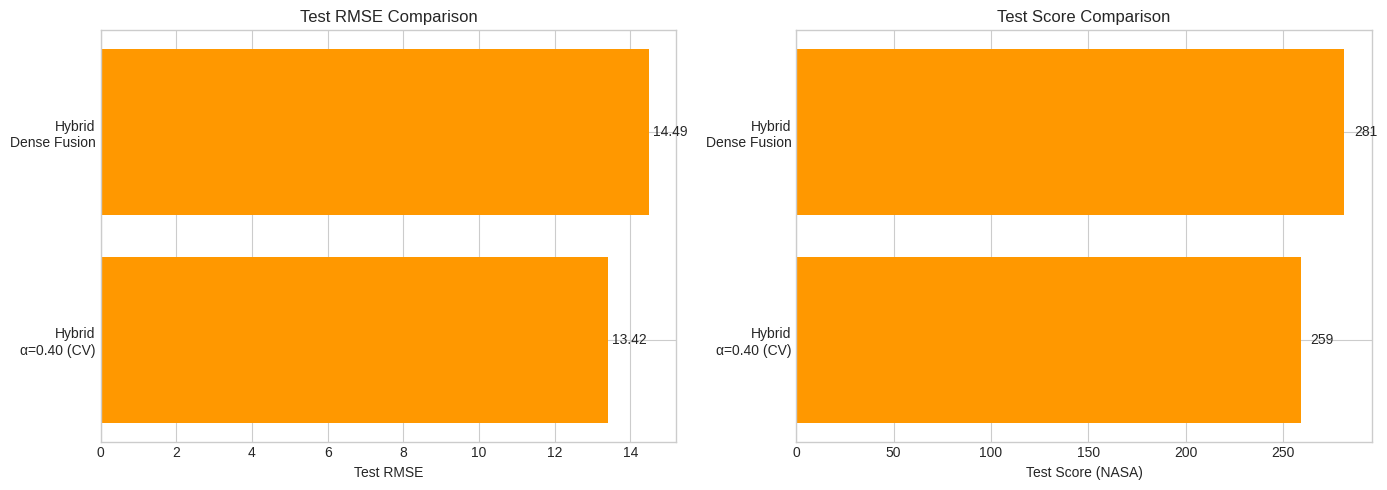

In [25]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [f"{r['Branch']}\n{r['Strategy']}" for _, r in comparison.iterrows()]
colors = ['#2196F3' if 'GA' in str(r['Strategy']) else
          '#4CAF50' if 'Grid' in str(r['Strategy']) else
          '#FF9800' for _, r in comparison.iterrows()]

axes[0].barh(labels, comparison['Test_RMSE'], color=colors)
axes[0].set_xlabel('Test RMSE')
axes[0].set_title('Test RMSE Comparison')
for i, v in enumerate(comparison['Test_RMSE']):
    axes[0].text(v + 0.1, i, f'{v:.2f}', va='center')

axes[1].barh(labels, comparison['Test_Score'], color=colors)
axes[1].set_xlabel('Test Score (NASA)')
axes[1].set_title('Test Score Comparison')
for i, v in enumerate(comparison['Test_Score']):
    axes[1].text(v + 5, i, f'{v:.0f}', va='center')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/D_comparison_chart_{TIMESTAMP}.png', dpi=150)
plt.show()

In [ ]:
# Scan all saved results from Drive
import json, os

drive_dir = '/content/drive/MyDrive/PhD_results/'
for folder in sorted(os.listdir(drive_dir)):
    path = os.path.join(drive_dir, folder)
    if os.path.isdir(path):
        print(f"\n📁 {folder}")
        for f in sorted(os.listdir(path)):
            if f.endswith('.json') and 'best' in f:
                with open(os.path.join(path, f), 'r') as fh:
                    data = json.load(fh)
                test_rmse = data.get('test_rmse', '—')
                test_score = data.get('test_score', '—')
                print(f"  {f}: RMSE={test_rmse}, Score={test_score}")

---
## Files saved:
```
PhD_results/W05_YYYYMMDD_HHMM/
    A_ml_grid_results_*.csv
    A_ml_grid_best_*.json
    B_dl_grid_results_*.csv
    B_dl_grid_best_*.json
    B_dl_grid_model_*.keras
    C1_alpha_fusion_*.json
    C2_dense_fusion_*.keras
    C2_dense_fusion_*.json
    D_final_comparison_*.csv
    D_comparison_chart_*.png
```